<a href="https://colab.research.google.com/github/Renurin/gerador-letra-musica/blob/main/Trabalho_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

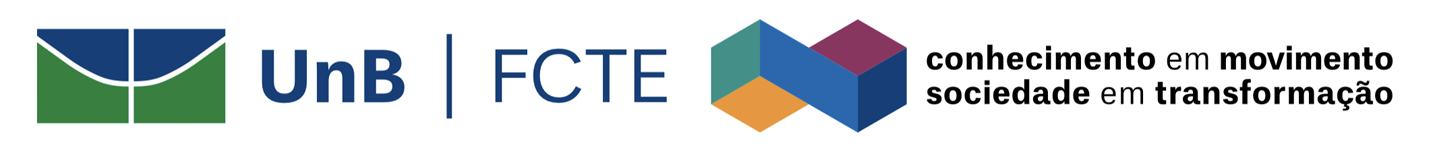


## Tópicos Especiais em Matemática Aplicada: Deep Learning
### Professor (Orientador): Vinicius Rispoli - FCTE/UnB

**Entrega em**: [Forms]

# Geração de Letras de Músicas
## Grupo:
- Renan Camara
- Matheus Villela
- João Victor Sousa Soares e Silva

## Contextualização:
As LLMs são grades redes que são treinadas com grandes quantidade de textos para entender e gerar linguagem humana.

A partir disso, surge o desafio da criação de texto criativo a partir delas, uma vez que o modelo só é capaz de prever a próxima palavra provável baseando-se no treinamento fornecido. Dessa forma, há um dilema entre a coerência e a criatividade.
- Se o modelo seguir o caminho lógico, criará textos repetitivos e seguros;
- Se o modelo tiver maior aleatoriedade, poderá criar textos desconexos e incoerentes.

## Objetivo:
O objetivo desse notebook é realizar o fine-tuning de uma rede Transformer (GPT-2) para gerar texto limitado à letras de músicas de acordo com o estilo musical e idioma.

## Jutificativa:
Atualmente, pela criação de grandes plataformas digitais para escutar músicas de diferentes estilos com apenas 1 clique, artistas podem se sentir sobrecarregados. Para tentar evitar isso, este modelo criará letras baseadas em como as músicas de certo estilo e idioma costumam ser. Dessa forma, é mais evidente que rumo ele deve seguir para evitar repetições e inovar na arte.

---

## Criação do Ambiente

In [ ]:
!pip install transformers datasets accelerate torch pandas scikit-learn
## Bibliotecas usadas normalmente
import pandas as pd
from sklearn.model_selection import train_test_split
## GPT-2 .-.
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from transformers import TextDataset, DataCollatorForLanguageModeling, Trainer, TrainingArguments

## Adquirir dados usando o Kaggle
https://www.kaggle.com/datasets/neisse/scrapped-lyrics-from-6-genres?resource=download&select=artists-data.csv

In [ ]:
# Pular as linhas ruins que aparentemente existem em lyrics-data
lyrics = pd.read_csv('lyrics-data.csv', engine='python', on_bad_lines='skip')
artists = pd.read_csv('artists-data.csv')

# Claro que nada vai funcionar de primeira
# Extrair nome de artira de 'ALink' em lyrics
lyrics['Artist_Name'] = lyrics['ALink'].apply(lambda x: x.strip('/').replace('-', ' ').title())

# Fundir as 2 a partir do ALink e a coluna Artista
df = lyrics.merge(artists[['Artist', 'Genres']], left_on='Artist_Name', right_on='Artist', how='left')

# Resolver o problema de 2 colunas com a mesma informação
df = df.drop(columns=['Artist_Name', 'Artist'])

print(df)

                 ALink                            SName  \
0      /ivete-sangalo/                            Arerê   
1      /ivete-sangalo/  Se Eu Não Te Amasse Tanto Assim   
2      /ivete-sangalo/                      Céu da Boca   
3      /ivete-sangalo/            Quando A Chuva Passar   
4      /ivete-sangalo/                     Sorte Grande   
...                ...                              ...   
16740  /elvis-presley/                            Danny   
16741  /elvis-presley/                        Danny Boy   
16742  /elvis-presley/                        Dark Moon   
16743  /elvis-presley/                           Datin'   
16744  /elvis-presley/                      Didja' Ever   

                                                   SLink  \
0                              /ivete-sangalo/arere.html   
1      /ivete-sangalo/se-eu-nao-te-amasse-tanto-assim...   
2                         /ivete-sangalo/chupa-toda.html   
3              /ivete-sangalo/quando-a-chuva-passar

# Tentativa 1: Filtrando 3 gêneros e 2 idiomas
Nessa tentativa, faremos o modelo simplificado usando apenas 3 gêneros e 2 idiomas (Rock, Hip Hop, Samba)

## Criar o texto de treinamento com TAGs especiais
formato: |Rock| |pt| (letra da música) |endoftext|

In [ ]:
# Filtro de generos e linguas
generos_alvo = ['Samba', 'Rock', 'Hip Hop']
linguagens_alvo = ['pt', 'en']

df_filtrado = df[
    (df['Genres'].isin(generos_alvo)) &
    (df['language'].isin(linguagens_alvo))
].dropna(subset=['Lyric', 'Genres'])

# Fiz uma função similiar a essa em compiladores o_o
def formatar_text(row):
  genre = row['Genres']
  language = row['language']
  lyrics = row['Lyric']
  return f"|{genre}| |{language}| {lyrics} |endoftext|"

# Função de filtro
df_filtrado['treino_formatado'] = df.apply(formatar_text, axis=1)


In [ ]:
# Salvar em txt para o modelo ler
texto_completo = "\n".join(df_filtrado['treino_formatado'].tolist())
with open("letras_musicas.txt", "w") as arquivo:
  arquivo.write(texto_completo)

print(f"Total de músicas para treino: {len(df_filtrado)}")
print("Exemplo formatado:\n", df_filtrado['treino_formatado'].iloc[0][:200])

Total de músicas para treino: 16745
Exemplo formatado:
 |Pop; Axé; Romântico| |pt| Tudo o que eu quero nessa vida,
Toda vida, é
É amar você
Amar você

O seu amor é como uma chama acesa
Queima de prazer
De prazer

Eu já falei com Deus que não vou te deixar



# Tokens e Modelo
- Usaremos o GPT-2 como base.

>É treinado em inglês, mas aprenderá português via transfer learning. GPT-2 lida melhor com o conjunto português e inglês quando comparado ao _pierreguillou/gpt2-small-portuguese_

In [ ]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel

# model_name = 'gpt2' descartado temporariamente por demorar demais
model_name = "distilgpt2"
tokenizer = GPT2Tokenizer.from_pretrained(model_name)

# 1 - Tokens especiais para diferenciar estilos e línguas
tokens_especiais = {
    'additional_special_tokens': [
        '|Rock|', '|Hip Hop|', '|Samba|', '|pt|', '|en|'
        ],
    'pad_token': '|pad|'
}

tokenizer.add_special_tokens(tokens_especiais)

# Redimencionar o modelo
model = GPT2LMHeadModel.from_pretrained(model_name)
model.resize_token_embeddings(len(tokenizer))

Embedding(50263, 768)

# Dataset e Treinamento
Criar um dataset compatível com o Pytorch e configurar o treinamento

In [ ]:
from transformers import TextDataset, DataCollatorForLanguageModeling, Trainer, TrainingArguments

# Criar o Dataset compatível com PyTorch
dataset = TextDataset(
    tokenizer=tokenizer,
    file_path="letras_musicas.txt",
    block_size=128 # Tamanho do bloco de texto
)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer, mlm=False
)

# Configuração do Treino (Pode demorar 1-2h no Colab grátis)
training_args = TrainingArguments(
    output_dir="./gpt2-multilang-music",
    overwrite_output_dir=True,
    num_train_epochs=5, # Aumentem para 5 se tiverem tempo
    per_device_train_batch_size=4,
    save_steps=5000,
    save_total_limit=2,
    logging_steps=500,
)

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=dataset,
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/transformers/data/datasets/language_modeling.py:53: FutureWarning: This dataset will be removed from the library soon, preprocessing should be handled with the 🤗 Datasets library. You can have a look at this example script for pointers: https://github.com/huggingface/transformers/blob/main/examples/pytorch/language-modeling/run_mlm.py
  warnings.warn(


Step,Training Loss
500,2.833900
1000,2.869800
1500,2.897300
2000,2.881000
2500,2.890200
3000,2.925800
3500,2.889100
4000,2.904100
4500,2.907400
5000,2.876600


TrainOutput(global_step=93455, training_loss=2.7843361903790593, metrics={'train_runtime': 6458.0115, 'train_samples_per_second': 57.885, 'train_steps_per_second': 14.471, 'total_flos': 1.220974391328768e+16, 'train_loss': 2.7843361903790593, 'epoch': 5.0})

# Salvar o modelo para teste

In [ ]:
trainer.save_model("./modelo_final")
tokenizer.save_pretrained("./modelo_final")
print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!


# Gerador de Letras

In [ ]:
# TEstar o modelo se pa
def gerar_musica(genero, lingua, inicio):
    # Constrói o prompt com as tags que a rede aprendeu
    prompt = f"|{genero}| |{lingua}| {inicio}"
    # Token
    inputs = tokenizer(prompt, return_tensors="pt", padding=True).to(model.device)

    # Geração
    sample_outputs = model.generate(
        inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        pad_token_id=tokenizer.pad_token_id,
        do_sample=True,
        max_length=200,
        top_k=50,
        top_p=0.95,
        temperature=1.0,
        repetition_penalty=1.2, # Ajuda a evitar loops
        num_return_sequences=1
    )

    texto_gerado = tokenizer.decode(sample_outputs[0], skip_special_tokens=True)
    print(f"--- {genero} ({lingua}) ---")
    print(texto_gerado)

# --- TESTES FINAIS ---
print("Gerar Samba em Português ->")
gerar_musica("Samba", "pt", "Meu coração diz")

print("\nGerando Rock uau em Inglês ->")
gerar_musica("Rock", "en", "The dark night")

print("\nTeste: Rock em Português -> ")
gerar_musica("Rock", "pt", "A escuridão")
# Mds esse modelo é péssimo com português

Gerar Samba em Português ->
--- Samba (pt) ---
  Meu coração diz
Vou te amar de tanto
Não é brincadeira, nada.

Deixe eu levar você
Quero ver passar
E quero beijar comigo

Um novo lance
Lê laia que o sol, que me fez a mãozinha. |endoftext|
|nan|  [Tupac Shakur]
Let's go to the future, all them days of day
Every single night I do my thing to make you see
They say
That tomorrow ain't what it feels like doing to us together
All day and night we could wait 'til tomorrow
So just let them feel some peace, for today
The best way is right and night
Let's move away from that will bring the lonely and we'll lead a better way
If your happiness on this here away

Gerando Rock uau em Inglês ->
--- Rock (en) ---
  The dark night's a new day, so bright
And I know that it willnt be, oh
'Cause it seems theres no tomorrow for me to make things better, oh (2x)

 |endoftext|
|nan|  Um grand final daqui fez o céu como e tem jeito você feliz
Com muita história e atabaquei
A gente sabe viver sem lugar e algu

# Correções
O merge gerado no início do código gerou colunas vazias que não foram limpas. Para resolver isso, removeremos as linhas onde genero, letras ou idioma forem nan.

In [ ]:
# começando de novo dos .csv
# Carregar e Merge igual antes
lyrics = pd.read_csv('lyrics-data.csv', engine='python', on_bad_lines='skip')
df_artists = pd.read_csv("artists-data.csv")

# Extrair nome de artista de 'ALink' em lyrics, similar ao que foi feito antes
lyrics['Artist_Name'] = lyrics['ALink'].astype(str).apply(lambda x: x.strip('/').replace('-', ' ').title())

# Fundir as 2 a partir de Artist_Name e a coluna Artist
df = lyrics.merge(df_artists[['Artist', 'Genres']], left_on='Artist_Name', right_on='Artist', how='left')

# Remover a coluna 'Artist_Name' que foi usada para o merge, se desejado
df = df.drop(columns=['Artist_Name', 'Artist'], errors='ignore')

# Initial dropna to remove rows with actual NaN values in key columns
df_cleaned = df.dropna(subset=['Genres', 'Lyric', 'language']).copy() # Added .copy() here

# Add an explicit filter to remove rows where 'Genres', 'Lyric', or 'language' are the string 'nan' (case-insensitive)
df_cleaned = df_cleaned[
    ~df_cleaned['Genres'].astype(str).str.lower().str.contains('nan', na=False) &
    ~df_cleaned['Lyric'].astype(str).str.lower().str.contains('nan', na=False) &
    ~df_cleaned['language'].astype(str).str.lower().str.contains('nan', na=False)
].copy()

generos_alvo = ['Samba', 'Rock', 'Hip Hop']
linguagens_alvo = ['pt', 'en']

# Function to extract a single target genre from a multi-genre string
def get_single_target_genre(genres_string, target_genres):
    if pd.isna(genres_string):
        return None
    individual_genres = [g.strip() for g in genres_string.split(';')]
    for g in individual_genres:
        if g in target_genres:
            return g # Return the first matching target genre
    return None # If no target genre found

# Apply this function to create a new 'Single_Genre' column
df_cleaned['Single_Genre'] = df_cleaned['Genres'].apply(lambda x: get_single_target_genre(x, generos_alvo))

# Filter based on the new 'Single_Genre' and language
df_filtered_final = df_cleaned[
    df_cleaned['Single_Genre'].notna() & # Ensure a target genre was found
    (df_cleaned['language'].astype(str).isin(linguagens_alvo))
].copy() # Added .copy() here to avoid SettingWithCopyWarning

# Formatação
def formatar_texto(row):
    # Use the pre-selected 'Single_Genre'
    genre_tag = row['Single_Genre']
    lingua = str(row['language']).strip()
    letra = str(row['Lyric']).strip()

    # Ensure they are not empty and not the string "nan"
    # Added checks for 'nan' string in lingua and letra
    if not genre_tag or str(genre_tag).lower() == 'nan':
        return None
    if not lingua or lingua.lower() == 'nan':
        return None
    if not letra or letra.lower() == 'nan':
        return None

    return f"|{genre_tag}| |{lingua}| {letra} |endoftext|"

df_filtered_final['treino_formatado'] = df_filtered_final.apply(formatar_texto, axis=1)

# Remove any rows where formatting returned None (due to unexpected 'nan' strings or empty values)
df_filtered_final = df_filtered_final.dropna(subset=['treino_formatado'])

# Then save to file
texto_completo = "\n".join(df_filtered_final['treino_formatado'].tolist())

# The check for "nan" will still be useful
if "nan" in texto_completo.lower():
    print("⚠️ ALERTA: Ainda existem 'nan' no texto! Verifique o CSV.")
else:
    print("✅ Sucesso: Dataset limpo e sem 'nan'.")

with open("letras_treino_multilang.txt", "w", encoding="utf-8") as f:
    f.write(texto_completo)

✅ Sucesso: Dataset limpo e sem 'nan'.


# Treinamento
Voltando ao treinamento de antes...

In [ ]:
# Copiado import do modelo para evitar caminhar pelo colab
from transformers import GPT2Tokenizer, GPT2LMHeadModel

# model_name = 'gpt2' descartado temporariamente por demorar demais
model_name = "distilgpt2"
tokenizer = GPT2Tokenizer.from_pretrained(model_name)

# 1 - Tokens especiais para diferenciar estilos e línguas
tokens_especiais = {
    'additional_special_tokens': [
        '|Rock|', '|Hip Hop|', '|Samba|', '|pt|', '|en|'
        ],
    'pad_token': '|pad|'
}

tokenizer.add_special_tokens(tokens_especiais)

# Redimencionar o modelo
model = GPT2LMHeadModel.from_pretrained(model_name)
model.resize_token_embeddings(len(tokenizer))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Embedding(50263, 768)

In [ ]:
from transformers import TextDataset, DataCollatorForLanguageModeling, Trainer, TrainingArguments

# treinamento atualizado
dataset = TextDataset(
    tokenizer=tokenizer,
    file_path="letras_treino_multilang.txt",
    block_size=64 # Tamanho do bloco de texto
)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer, mlm=False
)

# Configuração do Treino (Pode demorar 1-2h no Colab grátis)
training_args = TrainingArguments(
    output_dir="./gpt2-multilang-music",
    overwrite_output_dir=True,

    # VELOCIDADE PURA: Mixed Precision
    fp16=True,

    # Epochs
    num_train_epochs= 3,

    # 3. Batch e Acumulação: Menos atualizações de peso, mais velocidade
    per_device_train_batch_size= 64,
    gradient_accumulation_steps=4, # Efetivamente batch size = 32 (8 * 4)

    # Configurações auxiliares
    learning_rate=5e-5,
    save_steps=1000,
    logging_steps=100, # Log mais frequente para ver se travou
    warmup_steps=100,
)

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=dataset,
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/transformers/data/datasets/language_modeling.py:53: FutureWarning: This dataset will be removed from the library soon, preprocessing should be handled with the 🤗 Datasets library. You can have a look at this example script for pointers: https://github.com/huggingface/transformers/blob/main/examples/pytorch/language-modeling/run_mlm.py
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
100,4.134800
200,3.771500
300,3.650900
400,3.600200
500,3.560700
600,3.540200
700,3.514400
800,3.488200
900,3.478100
1000,3.459700


TrainOutput(global_step=5817, training_loss=3.3883291247457867, metrics={'train_runtime': 6088.9538, 'train_samples_per_second': 244.459, 'train_steps_per_second': 0.955, 'total_flos': 2.430877965955891e+16, 'train_loss': 3.3883291247457867, 'epoch': 3.0})